## Figure 1g
## Supplementary Figure 15

## Helper codes: run below cells before any of the other cells. 

In [1]:
from pynwb import NWBHDF5IO
from scipy.io import savemat, loadmat
import mat73
import hdf5storage as st
import pickle
from pathlib import Path
import ast
import json
import gzip

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap

from sklearn.decomposition import PCA
from sklearn.manifold import Isomap, TSNE
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc
from sklearn.neighbors import NearestNeighbors, KNeighborsClassifier

from scipy.sparse.linalg import eigsh
from scipy.stats import wilcoxon, kruskal, mannwhitneyu, sem, kstest, pearsonr, spearmanr
from scipy.optimize import curve_fit
from scipy.ndimage import maximum_filter1d
from scipy.spatial.distance import cdist

import seaborn as sns
from copy import deepcopy as dc
from statsmodels.stats.multitest import multipletests
# from statannot import add_stat_annotation

from itertools import combinations, product
import math
from umap import UMAP
from time import time
from copy import deepcopy as dc

# # tell pandas to show all columns when we display a DataFrame
# pd.set_option("display.max_columns", None)

c:\Users\USER\anaconda3\envs\allensdk_ep_mod_test\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# loading
with gzip.open('resp_matrix_ep_all_Ecker.pickle.gz', 'rb') as f:
    resp_matrix_ep_all = pickle.load(f)
    
    list_rate_all = resp_matrix_ep_all['list_rate_all'].copy()
    list_slopes_all_att_loglog = resp_matrix_ep_all['list_slopes_all_att_loglog'].copy()
    list_slopes_all_an_loglog = resp_matrix_ep_all['list_slopes_all_an_loglog'].copy()
    sess_inds_qual_all = resp_matrix_ep_all['sess_inds_qual_all'].copy() # indices of sessions with >=15 neurons
    subject_ids = resp_matrix_ep_all['subject_ids'].copy() # subject id 30 (M2) has 17 sessions, 31 (M1) has 15 sessions
    
    # # session pooling, match to minimum num_trials
    # list_rate_shuf_pooled = resp_matrix_ep_all['list_rate_shuf_pooled'].copy() # session index 0 is monkey 30, session index 1 is monkey 31
    # list_slopes_all_att_loglog_pooled = resp_matrix_ep_all['list_slopes_all_att_loglog_pooled'].copy()
    # list_slopes_all_an_loglog_pooled = resp_matrix_ep_all['list_slopes_all_an_loglog_pooled'].copy()

    # session pooling, preserve num_trials
    list_slopes_all_att_loglog_pooled_raw = resp_matrix_ep_all['list_slopes_all_att_loglog_pooled_raw'].copy() # use raw data mean, var
    list_slopes_all_an_loglog_pooled_raw = resp_matrix_ep_all['list_slopes_all_an_loglog_pooled_raw'].copy()

    # # session pooling, bootstrap 50 trials
    # list_rate_shuf_pooled_trialresamp = resp_matrix_ep_all['list_rate_shuf_pooled_trialresamp'].copy()
    # list_slopes_all_att_loglog_pooled_trialresamp = resp_matrix_ep_all['list_slopes_all_att_loglog_pooled_trialresamp'].copy()
    # list_slopes_all_an_loglog_pooled_trialresamp = resp_matrix_ep_all['list_slopes_all_an_loglog_pooled_trialresamp'].copy()

    # # session pooling, match to minimum num_trials, resample neurons
    # list_rate_pooled_resamp = resp_matrix_ep_all['list_rate_pooled_resamp'].copy()
    # list_resamp_inds = resp_matrix_ep_all['list_resamp_inds'].copy() # resampled neuron indices
    # list_slopes_all_att_loglog_pooled_resamp = resp_matrix_ep_all['list_slopes_all_att_loglog_pooled_resamp'].copy()
    # list_slopes_all_an_loglog_pooled_resamp = resp_matrix_ep_all['list_slopes_all_an_loglog_pooled_resamp'].copy()

    # session pooling, bootstrap 50 trials, resample neurons
    list_rate_pooled_neutrialresamp = resp_matrix_ep_all['list_rate_pooled_neutrialresamp'].copy()
    list_slopes_all_att_loglog_pooled_resampraw = resp_matrix_ep_all['list_slopes_all_att_loglog_pooled_resampraw'].copy() # use raw data mean, var
    list_slopes_all_an_loglog_pooled_resampraw = resp_matrix_ep_all['list_slopes_all_an_loglog_pooled_resampraw'].copy()

In [3]:
def compute_mean_var_trial(label_cnt_dict, rate_sorted):    
    list_trial_mean = [[0]] * len(label_cnt_dict)
    list_trial_var = [[0]] * len(label_cnt_dict)

    for trial_ind, trial_type in enumerate(label_cnt_dict):
        
        trial_rate = np.array(rate_sorted.loc[:, trial_type])                
        trial_mean = np.mean(trial_rate, axis=1)
        trial_var = np.var(trial_rate, axis=1, ddof=1)

        trial_mean = pd.DataFrame(trial_mean, columns=[trial_type], index=rate_sorted.index)
        trial_var = pd.DataFrame(trial_var, columns=[trial_type], index=rate_sorted.index)
        list_trial_mean[trial_ind] = pd.concat([trial_mean] * label_cnt_dict[trial_type], axis=1)
        list_trial_var[trial_ind] = pd.concat([trial_var] * label_cnt_dict[trial_type], axis=1)

    rate_sorted_mean = pd.concat(list_trial_mean, axis=1)
    rate_sorted_var = pd.concat(list_trial_var, axis=1)

    return rate_sorted_mean, rate_sorted_var

In [4]:
def compute_mean_var_trial_collapse(label_cnt_dict, rate_sorted):    
    list_trial_mean = [[0]] * len(label_cnt_dict)
    list_trial_var = [[0]] * len(label_cnt_dict)

    for trial_ind, trial_type in enumerate(label_cnt_dict):
        
        trial_rate = np.array(rate_sorted.loc[:, trial_type])                
        trial_mean = np.mean(trial_rate, axis=1, dtype=np.longdouble)
        trial_var = np.var(trial_rate, axis=1, ddof=1, dtype=np.longdouble)

        trial_mean = pd.DataFrame(trial_mean, columns=[trial_type], index=rate_sorted.index)
        trial_var = pd.DataFrame(trial_var, columns=[trial_type], index=rate_sorted.index)
        list_trial_mean[trial_ind] = trial_mean.copy()
        list_trial_var[trial_ind] = trial_var.copy()

    rate_sorted_mean = pd.concat(list_trial_mean, axis=1)
    rate_sorted_var = pd.concat(list_trial_var, axis=1)

    return rate_sorted_mean, rate_sorted_var

In [5]:
def annotate_lineplot_significance(significant_values, axes, ax_ind, line_height_ratio, color):

    if len(significant_values) > 0:

        # Initialize start and end points of lines
        start = None
        lines = []
        dots = []

        # Loop through sorted significant_values to group them into lines or dots
        for i in range(len(significant_values) - 1):
            if start is None:
                start = significant_values[i]

            # Check if the next value is part of the same line
            if significant_values[i + 1] - significant_values[i] > 0.1 + 1e-9:  # Threshold for a gap; add pseudo-value to avoid floating point issue
                if start == significant_values[i]:
                    dots.append(start)  # Isolated point
                else:
                    lines.append((start, significant_values[i]))  # Line segment
                start = None

        # Check the last value
        if start is None:
            dots.append(significant_values[-1])
        else:
            lines.append((start, significant_values[-1]))

        # Plot lines and dots
        for line in lines:
            if isinstance(axes, np.ndarray):
                axes[ax_ind].hlines(axes[ax_ind].get_ylim()[0]+(axes[ax_ind].get_ylim()[1]-axes[ax_ind].get_ylim()[0])*line_height_ratio, \
                    xmin=line[0], xmax=line[1], colors=color)  # Draw a line
            elif isinstance(axes, plt.Axes):
                axes.hlines(axes.get_ylim()[0]+(axes.get_ylim()[1]-axes.get_ylim()[0])*line_height_ratio, \
                    xmin=line[0], xmax=line[1], colors=color)
            else:
                plt.hlines(plt.gca().get_ylim()[0]+(plt.gca().get_ylim()[1]-plt.gca().get_ylim()[0])*line_height_ratio, \
                    xmin=line[0], xmax=line[1], colors=color)
                
        for dot in dots:
            if isinstance(axes, np.ndarray):
                axes[ax_ind].hlines(axes[ax_ind].get_ylim()[0]+(axes[ax_ind].get_ylim()[1]-axes[ax_ind].get_ylim()[0])*line_height_ratio, \
                    xmin=dot-0.01, xmax=dot+0.01, colors=color)  # Draw a very short line
            elif isinstance(axes, plt.Axes):
                axes.hlines(axes.get_ylim()[0]+(axes.get_ylim()[1]-axes.get_ylim()[0])*line_height_ratio, \
                    xmin=dot-0.01, xmax=dot+0.01, colors=color)
            else:
                plt.hlines(plt.gca().get_ylim()[0]+(plt.gca().get_ylim()[1]-plt.gca().get_ylim()[0])*line_height_ratio, \
                    xmin=dot-0.01, xmax=dot+0.01, colors=color)

In [6]:
def get_upper_whisker(data, whis=1.5):
    """Calculates the top of the upper whisker (ignoring hidden outliers)."""
    data = np.array(data)
    q1 = np.nanpercentile(data, 25)
    q3 = np.nanpercentile(data, 75)
    iqr = q3 - q1
    upper_bound = q3 + whis * iqr
    valid_points = data[data <= upper_bound]
    
    return np.nanmax(valid_points) if len(valid_points) > 0 else np.nanmax(data)

def add_significance_bars(ax, comparisons, y_max_values, x_positions=None, p_values=None, 
                          gap_below_line=0.4, gap_below_text=0.1, bottomline_offset=1, fontsize=10, ignore_ns=True):

    if p_values is None: p_values = ['*' for _ in comparisons]
    if x_positions is None: x_positions = np.arange(len(y_max_values))
    if ignore_ns:
        pval_thres = 0.05
    else:
        pval_thres = 1
    
    # Sort Comparisons: Distance first, then height
    def sort_key(item):
        (idx1, idx2), _ = item
        x_min, x_max = min(idx1, idx2), max(idx1, idx2)
        dist = x_max - x_min
        height = max(y_max_values[x_min : x_max + 1])
        return (dist, height)

    combined = list(zip(comparisons, p_values))
    combined.sort(key=sort_key)
    sorted_comparisons, sorted_p_values = zip(*combined)
    
    # Scale Factors
    y_min, y_max = np.nanmin(y_max_values), np.nanmax(y_max_values)
    y_range = y_max - y_min if y_max != y_min else 1.0

    # Get physical figure size in inches
    fig = ax.get_figure()
    fig_height_inch = fig.get_figheight()
    
    # Get axis height in fraction of figure (e.g., 0.8)
    bbox = ax.get_position()
    ax_height_inch = fig_height_inch * bbox.height

    # Get current Y-axis range (data units)
    y_min, y_max = ax.get_ylim()
    y_range_real = y_max - y_min

    # Conversion: (Points / 72 inch/pt) * (Data Range / Axis Height inches)
    text_height_data = (fontsize / 72) * (y_range_real / ax_height_inch)
    
    # Define gaps relative to the text size
    clearance = text_height_data * gap_below_line
    text_height = text_height_data
    
    # Initialize Interval Skyline
    # If we have N columns, we have N-1 gaps.
    n_columns = len(y_max_values)
    interval_skyline = [0] * (n_columns - 1)
    
    # Draw Bars
    for com_ind, ((idx1, idx2), pval) in enumerate(zip(sorted_comparisons, sorted_p_values)):
        if pval <= pval_thres:
            x1, x2 = min(idx1, idx2), max(idx1, idx2)
            
            # Check Data Height
            data_peak = np.nanmax(y_max_values[x1 : x2 + 1])
            
            # Check Interval Height
            if x1 < x2:
                interval_peak = np.nanmax(interval_skyline[x1:x2]) if interval_skyline[x1:x2] else 0
            else:
                interval_peak = 0
                
            # Determine drawing height
            # Must clear both the data and the previous bars below it
            y_line = np.nanmax([data_peak, interval_peak]) + clearance
            
            # if adjacent bars have same height, move up the second one
            if com_ind >= 1:
                idx1_prev, idx2_prev = sorted_comparisons[com_ind-1]
                x1_prev, x2_prev = min(idx1_prev, idx2_prev), max(idx1_prev, idx2_prev)
                pval_prev = sorted_p_values[com_ind-1]
                if x2 - x1 == 1 and x2_prev - x1_prev == 1 and x1 == x2_prev and pval_prev <= pval_thres:
                    y_line_prev = interval_skyline[x1_prev] - text_height
                    if np.isclose(y_line, y_line_prev):
                        y_line += clearance * bottomline_offset

            # Draw Line
            x_pos1, x_pos2 = x_positions[x1], x_positions[x2]
            line_x = [x_pos1, x_pos2]
            line_y = [y_line, y_line]
            ax.plot(line_x, line_y, lw=1.5, c='k')
        
            # Add Text
            text_y = y_line + (clearance * gap_below_text)
            if pval < 0.001:
                asterisk = '***'
            elif pval < 0.01:
                asterisk = '**'
            elif pval < 0.05:
                asterisk = '*'
            else:
                asterisk = f'p={pval:.2f}'
            ax.text((x_pos1 + x_pos2) * 0.5, text_y, asterisk, ha='center', va='bottom', color='k')
            
            # Update Interval Skyline
            new_height = y_line + text_height
            for k in range(x1, x2):
                interval_skyline[k] = new_height

    return ax

In [7]:
# Function to compute cosine similarity
def cos_sim(x, y):
    # x and y are 1D vectors

    # Remove NaN
    x, y = np.array(x), np.array(y)
    bool_notnan = np.logical_and(~np.isnan(x), ~np.isnan(y))
    x, y = x[bool_notnan].copy(), y[bool_notnan].copy()

    return np.dot(x, y) / (np.linalg.norm(x) * np.linalg.norm(y))

In [8]:
# monkey session pooling
num_trial_types = 75
unique_ids = np.unique(subject_ids)
# list_rate_shuf_pooled = np.empty(len(unique_ids), dtype=object)
list_rate_shuf_pooled_trialresamp = np.empty(len(unique_ids), dtype=object)
rng = np.random.default_rng(0)
for monkey_ind, monkey_id in enumerate(unique_ids):
    sess_inds = np.where(subject_ids == monkey_id)[0]
    
    # # 1. minimum number of trials for all stimuli
    # list_num_trials = np.zeros((len(sess_inds), num_trial_types), dtype=int)
    # for ind, sess_ind in enumerate(sess_inds):
    #     _, list_num_trials[ind] = np.unique(list_rate_all[sess_ind].columns, return_counts=True)
    # list_min_num_trials = np.min(list_num_trials, axis=0).astype(int) # minimum num_trials for each stimulus in this monkey

    # list_rate_min = np.empty(len(sess_inds), dtype=object)
    # for ind, sess_ind in enumerate(sess_inds):
    #     rate_sorted = list_rate_all[sess_ind].sort_index(axis=1)
    #     all_stm_unique, all_stm_counts = np.unique(rate_sorted.columns, return_counts=True)
    #     rate_min = pd.DataFrame(np.full((rate_sorted.shape[0], np.sum(list_min_num_trials)), np.nan),
    #                              columns=np.repeat(all_stm_unique, list_min_num_trials))
    #     for trial_type_ind, trial_type in enumerate(all_stm_unique):
    #         rate_shuf = rng.permuted(rate_sorted.loc[:, trial_type].values, axis=1) # destroy noise correlation
    #         rate_min.loc[:, trial_type] = rate_shuf[:, :list_min_num_trials[trial_type_ind]].copy()
    #     list_rate_min[ind] = rate_min.copy()
    # list_rate_shuf_pooled[monkey_ind] = pd.concat(list_rate_min, axis=0).reset_index(drop=True)

    # 2. resample 50 trials for all stimuli
    list_rate_resamp = np.empty(len(sess_inds), dtype=object)
    num_trials_resamp = 50
    for ind, sess_ind in enumerate(sess_inds):
        rate_sorted = list_rate_all[sess_ind].sort_index(axis=1)
        num_neurons_temp = rate_sorted.shape[0]
        all_stm_unique, all_stm_counts = np.unique(rate_sorted.columns, return_counts=True)
        rate_resamp = pd.DataFrame(np.full((rate_sorted.shape[0], num_trial_types*num_trials_resamp), np.nan),
                                   columns=np.repeat(all_stm_unique, num_trials_resamp))
        for trial_type_ind, trial_type in enumerate(all_stm_unique):
            rate_tt = rate_sorted.loc[:, trial_type].values
            num_trials_temp = rate_tt.shape[1]
            list_trial_resamp_inds = [rng.choice(range(num_trials_temp), num_trials_resamp, replace=True) for neu_ind in range(num_neurons_temp)] # trial resampling
            list_trial_resamp_inds = np.array(list_trial_resamp_inds).T # (num_trials_resamp, num_neurons_temp)
            rate_shuf = rng.permuted(rate_tt, axis=1) # destroy noise correlation
            rate_resamp.loc[:, trial_type] = rate_shuf[np.arange(num_neurons_temp), list_trial_resamp_inds].T
        list_rate_resamp[ind] = rate_resamp.copy()
    list_rate_shuf_pooled_trialresamp[monkey_ind] = pd.concat(list_rate_resamp, axis=0).reset_index(drop=True)

In [9]:
# # spike count
# base_path = Path('monkey_Ecker\\v1_data\\test\\')
# num_sess = len([p for p in base_path.iterdir()])
# print(f'num_sess = {num_sess}')
# # list_rate_all = np.empty(num_sess, dtype=object)
# subject_ids = np.zeros(num_sess, dtype=int)
# for sess_ind, p in enumerate(base_path.iterdir()):
#     print(f'sess_ind {sess_ind}')
    
#     metadata_name = 'meta_data.json'
#     response_name = 'responses.csv'
#     file_path_meta = str(base_path) + '\\' + p.name + '\\' + metadata_name
#     file_path_res = str(base_path) + '\\' + p.name + '\\' + response_name

#     with gzip.open(file_path_meta, 'r') as f:
#         meta = json.load(f)
#         # print(meta['subject_id']) # subject id 30 (M2) has 17 sessions, 31 (M1) has 15 sessions
#         subject_ids[sess_ind] = meta['subject_id']

#     # df = pd.read_csv(file_path_res)
#     # stims = df.loc[:, 'image_id'].copy()
#     # num_tot_trials = len(stims)
#     # num_neurons = np.array(ast.literal_eval(df.loc[0, 'responses'])).shape[0]
    
#     # spkcnt = np.full((num_neurons, num_tot_trials), np.nan)
#     # for trial_ind in range(num_tot_trials):
#     #     psth = np.array(ast.literal_eval(df.loc[trial_ind, 'responses'])).copy()
#     #     spkcnt[:, trial_ind] = np.sum(psth, axis=1)
#     # list_rate_all[sess_ind] = pd.DataFrame(spkcnt, columns=stims).copy()

## Codes for figures

## Figure 1g

In [10]:
# # Linear Fitting Slope across stimuli (ABO Neuropixels all neurons) (loglog line) (monkey session pooling, use raw data mean, var)

# # collect raw data mean, var for each monkey
# num_sess = len(list_rate_all)
# unique_ids = np.unique(subject_ids)
# num_trial_types = 75
# mean_temp = [[] for monkey_ind in range(len(unique_ids))]
# var_temp = [[] for monkey_ind in range(len(unique_ids))]
# rate_sorted_mean_coll_pooled = np.empty(len(unique_ids), dtype=object)
# rate_sorted_var_coll_pooled = np.empty(len(unique_ids), dtype=object)
# for monkey_ind, monkey_id in enumerate(unique_ids):
#     sess_inds = np.where(subject_ids == monkey_id)[0]
#     for ind, sess_ind in enumerate(sess_inds):
#         # print(f'session index: {sess_ind}')
        
#         rate = list_rate_all[sess_ind].sort_index(axis=1)
#         stm = rate.columns.copy()

#         # Create a counting dictionary for each stimulus
#         all_stm_unique, all_stm_counts = np.unique(stm, return_counts=True)
#         stm_cnt_dict = dict(zip(all_stm_unique, all_stm_counts))

#         # Compute mean & variance for each stimulus
#         rate_sorted_mean, rate_sorted_var = compute_mean_var_trial(stm_cnt_dict, rate)
#         rate_sorted_mean_coll, rate_sorted_var_coll = compute_mean_var_trial_collapse(stm_cnt_dict, rate)
#         mean_temp[monkey_ind].append(rate_sorted_mean_coll)
#         var_temp[monkey_ind].append(rate_sorted_var_coll)
#     rate_sorted_mean_coll_pooled[monkey_ind] = np.concatenate(mean_temp[monkey_ind], axis=0)
#     rate_sorted_var_coll_pooled[monkey_ind] = np.concatenate(var_temp[monkey_ind], axis=0)

# # Iterate over all sessions
# num_sess = len(list_rate_shuf_pooled_trialresamp)
# n_resampling = 15
# num_trial_types = 75
# num_trials_resamp = 50
# list_slopes_all_att_loglog_pooled_raw = np.empty(num_sess, dtype=object)
# for sess_ind, rate in enumerate(list_rate_shuf_pooled_trialresamp):
#     # if sess_ind in sess_inds_qual_all:
#         print(f'session index: {sess_ind}')
        
#         monkey_ind = sess_ind
#         rate_sorted_mean_coll, rate_sorted_var_coll = pd.DataFrame(rate_sorted_mean_coll_pooled[monkey_ind]), pd.DataFrame(rate_sorted_var_coll_pooled[monkey_ind])
#         rate_sorted_mean = pd.DataFrame(np.repeat(rate_sorted_mean_coll.values, num_trials_resamp, axis=1),
#                                         columns=np.repeat(range(num_trial_types), num_trials_resamp))
#         rate_sorted_var = pd.DataFrame(np.repeat(rate_sorted_var_coll.values, num_trials_resamp, axis=1),
#                                        columns=np.repeat(range(num_trial_types), num_trials_resamp))
        
#         # Calculate and collect linear slopes for all neurons
#         slopes = np.zeros((2, rate_sorted_mean_coll.shape[0]))
#         for neu_ind in rate_sorted_mean_coll.index:
#             # loglog scale
#             bool_mean_notzero = rate_sorted_mean_coll.loc[neu_ind] > 0
#             popt = np.polyfit(np.log10(rate_sorted_mean.loc[neu_ind, bool_mean_notzero].values).flatten().astype(np.float32), \
#                                 np.log10(rate_sorted_var.loc[neu_ind, bool_mean_notzero].values).flatten().astype(np.float32), 1)
            
#             slopes[:, neu_ind] = popt.copy()
#         list_slopes_all_att_loglog_pooled_raw[sess_ind] = slopes.copy()

In [11]:
# # Linear Fitting Slope across neurons (ABO Neuropixels all neurons) (loglog line) (monkey session pooling, use raw data mean, var)

# # collect raw data mean, var for each monkey
# num_sess = len(list_rate_all)
# unique_ids = np.unique(subject_ids)
# num_trial_types = 75
# mean_temp = [[] for monkey_ind in range(len(unique_ids))]
# var_temp = [[] for monkey_ind in range(len(unique_ids))]
# rate_sorted_mean_coll_pooled = np.empty(len(unique_ids), dtype=object)
# rate_sorted_var_coll_pooled = np.empty(len(unique_ids), dtype=object)
# for monkey_ind, monkey_id in enumerate(unique_ids):
#     sess_inds = np.where(subject_ids == monkey_id)[0]
#     for ind, sess_ind in enumerate(sess_inds):
#         # print(f'session index: {sess_ind}')
        
#         rate = list_rate_all[sess_ind].sort_index(axis=1)
#         stm = rate.columns.copy()

#         # Create a counting dictionary for each stimulus
#         all_stm_unique, all_stm_counts = np.unique(stm, return_counts=True)
#         stm_cnt_dict = dict(zip(all_stm_unique, all_stm_counts))

#         # Compute mean & variance for each stimulus
#         rate_sorted_mean, rate_sorted_var = compute_mean_var_trial(stm_cnt_dict, rate)
#         rate_sorted_mean_coll, rate_sorted_var_coll = compute_mean_var_trial_collapse(stm_cnt_dict, rate)
#         mean_temp[monkey_ind].append(rate_sorted_mean_coll)
#         var_temp[monkey_ind].append(rate_sorted_var_coll)
#     rate_sorted_mean_coll_pooled[monkey_ind] = np.concatenate(mean_temp[monkey_ind], axis=0)
#     rate_sorted_var_coll_pooled[monkey_ind] = np.concatenate(var_temp[monkey_ind], axis=0)

# # Iterate over all sessions
# num_sess = len(list_rate_shuf_pooled_trialresamp)
# n_resampling = 15
# num_trial_types = 75
# num_trials_resamp = 50
# list_slopes_all_an_loglog_pooled_raw = np.empty(num_sess, dtype=object)
# for sess_ind, rate in enumerate(list_rate_shuf_pooled_trialresamp):
#     # if sess_ind in sess_inds_qual_all:
#         print(f'session index: {sess_ind}')

#         monkey_ind = sess_ind
#         rate_sorted_mean_coll, rate_sorted_var_coll = pd.DataFrame(rate_sorted_mean_coll_pooled[monkey_ind]), pd.DataFrame(rate_sorted_var_coll_pooled[monkey_ind])
#         rate_sorted_mean = pd.DataFrame(np.repeat(rate_sorted_mean_coll.values, num_trials_resamp, axis=1),
#                                         columns=np.repeat(range(num_trial_types), num_trials_resamp))
#         rate_sorted_var = pd.DataFrame(np.repeat(rate_sorted_var_coll.values, num_trials_resamp, axis=1),
#                                        columns=np.repeat(range(num_trial_types), num_trials_resamp))
        
#         # Calculate and collect linear slopes for all stimuli
#         slopes = np.zeros((2, rate_sorted_mean_coll.shape[1]))
#         for trial_type_ind, trial_type in enumerate(rate_sorted_mean_coll.columns):
#             # loglog scale
#             bool_mean_notzero = rate_sorted_mean_coll.loc[:, trial_type] != 0
#             popt = np.polyfit(np.log10(rate_sorted_mean.loc[bool_mean_notzero, trial_type].values).flatten().astype(np.float32), \
#                                 np.log10(rate_sorted_var.loc[bool_mean_notzero, trial_type].values).flatten().astype(np.float32), 1)
            
#             slopes[:, trial_type_ind] = popt.copy()
#         list_slopes_all_an_loglog_pooled_raw[sess_ind] = slopes.copy()

across trial types Mean 1.0376941926280063, Std 0.1925672260003645, IQR 0.20741577303236047, SEM 0.008998075549887031
across neurons Mean 0.9906925730386171, Std 0.03689027903205467, IQR 0.05577937061620053, SEM 0.003012078669914242


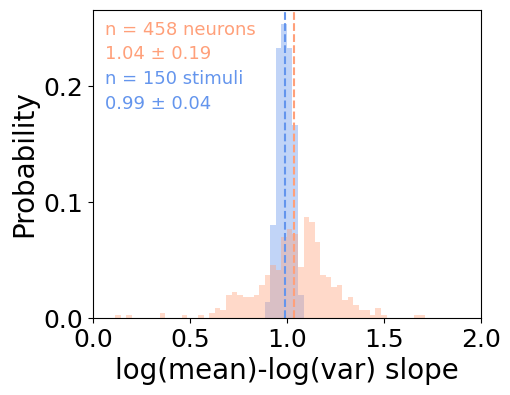

In [12]:
# loglog linear slope across trial types vs. across neurons (monkey session pooling, use raw data mean, var)

list_slopes_all_att_loglog_pooled_raw_flattened = np.concatenate([slopes[0, :].flatten() for sess_ind, slopes in enumerate(list_slopes_all_att_loglog_pooled_raw)])
list_slopes_all_an_loglog_pooled_raw_flattened = np.concatenate([slopes[0, :].flatten() for sess_ind, slopes in enumerate(list_slopes_all_an_loglog_pooled_raw)])

# histogram
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
lower_bound, upper_bound = 0, 2
n_bins = 70

# across trial types
# weights = np.ones_like(list_slopes_all_att_loglog_pooled_raw_flattened)
weights = np.ones_like(list_slopes_all_att_loglog_pooled_raw_flattened) / len(list_slopes_all_att_loglog_pooled_raw_flattened)
ax.hist(list_slopes_all_att_loglog_pooled_raw_flattened, bins=n_bins, range=(lower_bound, upper_bound), \
        weights=weights, color='lightsalmon', alpha=0.4, label='LMLV$_{neuron}$', zorder=2)
ax.axvline(np.nanmean(list_slopes_all_att_loglog_pooled_raw_flattened), color='lightsalmon', linestyle='--')
print(f'across trial types Mean {np.nanmean(list_slopes_all_att_loglog_pooled_raw_flattened)}, Std {np.std(list_slopes_all_att_loglog_pooled_raw_flattened, ddof=1)}, \
IQR {np.nanpercentile(list_slopes_all_att_loglog_pooled_raw_flattened, 75) - np.nanpercentile(list_slopes_all_att_loglog_pooled_raw_flattened, 25)}, \
SEM {sem(list_slopes_all_att_loglog_pooled_raw_flattened)}')

# across neurons
# weights = np.ones_like(list_slopes_all_an_loglog_pooled_raw_flattened)
weights = np.ones_like(list_slopes_all_an_loglog_pooled_raw_flattened) / len(list_slopes_all_an_loglog_pooled_raw_flattened)
ax.hist(list_slopes_all_an_loglog_pooled_raw_flattened, bins=n_bins, range=(lower_bound, upper_bound), \
        weights=weights, color='cornflowerblue', alpha=0.4, label='LMLV$_{stim}$', zorder=1)
ax.axvline(np.nanmean(list_slopes_all_an_loglog_pooled_raw_flattened), color='cornflowerblue', linestyle='--')
print(f'across neurons Mean {np.nanmean(list_slopes_all_an_loglog_pooled_raw_flattened)}, Std {np.std(list_slopes_all_an_loglog_pooled_raw_flattened, ddof=1)}, \
IQR {np.nanpercentile(list_slopes_all_an_loglog_pooled_raw_flattened, 75) - np.nanpercentile(list_slopes_all_an_loglog_pooled_raw_flattened, 25)}, \
SEM {sem(list_slopes_all_an_loglog_pooled_raw_flattened)}')

ax.set_xlabel('log(mean)-log(var) slope', fontsize=20)
ax.set_ylabel('Probability', fontsize=20)
ax.set_xticks([0, 0.5, 1, 1.5, 2])
ax.set_yticks(np.arange(0, ax.get_ylim()[1], 0.1))
ax.tick_params('both', labelsize=18)
# ax.legend(loc='upper left', prop={'size': 14})
# ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), prop={'size': 14})

ax.set_xlim(0, 2)
ax.annotate(f'n = {list_slopes_all_att_loglog_pooled_raw_flattened.shape[0]} neurons', xy=(0.03, 0.92), xycoords='axes fraction', fontsize=13, color='lightsalmon')
# ax.annotate(f'{np.mean(list_slopes_all_att_loglog_pooled_raw_flattened):.3f} ± {sem(list_slopes_all_att_loglog_pooled_raw_flattened):.3f}', xy=(0.03, 0.84), xycoords='axes fraction', fontsize=13, color='lightsalmon')
ax.annotate(f'{np.mean(list_slopes_all_att_loglog_pooled_raw_flattened):.2f} ± {np.std(list_slopes_all_att_loglog_pooled_raw_flattened, ddof=1):.2f}', xy=(0.03, 0.84), xycoords='axes fraction', fontsize=13, color='lightsalmon')
ax.annotate(f'n = {list_slopes_all_an_loglog_pooled_raw_flattened.shape[0]} stimuli', xy=(0.03, 0.76), xycoords='axes fraction', fontsize=13, color='cornflowerblue')
# ax.annotate(f'{np.mean(list_slopes_all_an_loglog_pooled_raw_flattened):.3f} ± {sem(list_slopes_all_an_loglog_pooled_raw_flattened):.3f}', xy=(0.03, 0.68), xycoords='axes fraction', fontsize=13, color='cornflowerblue')
ax.annotate(f'{np.mean(list_slopes_all_an_loglog_pooled_raw_flattened):.2f} ± {np.std(list_slopes_all_an_loglog_pooled_raw_flattened, ddof=1):.2f}', xy=(0.03, 0.68), xycoords='axes fraction', fontsize=13, color='cornflowerblue')

# plt.savefig('code_images\\svg\\monkey_slope_histogram_pooled_raw_asis_2cond.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\monkey_slope_histogram_pooled_raw_asis_2cond.png', dpi=300, bbox_inches='tight')
plt.show()

across trial types Mean 0.10996514146488245, Std 0.1412221963233066, IQR 0.16706785835651633
across neurons Mean 0.08756085876285125, Std 0.027349119007573308, IQR 0.041601637521625545


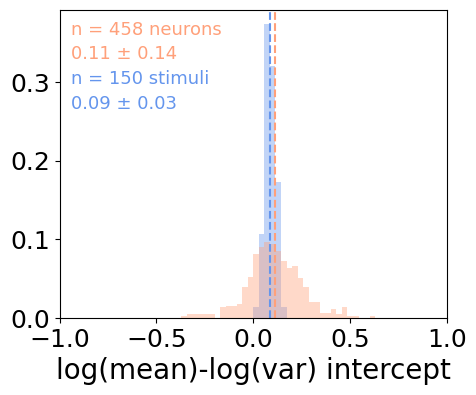

In [13]:
# loglog linear intercept across trial types vs. across neurons (monkey session pooling, use raw data mean, var)
list_intcpts_all_att_loglog_pooled_raw_flattened = np.concatenate([slopes[1, :].flatten() for sess_ind, slopes in enumerate(list_slopes_all_att_loglog_pooled_raw)])
list_intcpts_all_an_loglog_pooled_raw_flattened = np.concatenate([slopes[1].flatten() for sess_ind, slopes in enumerate(list_slopes_all_an_loglog_pooled_raw)])

# 1. histogram
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
lower_bound, upper_bound = -1, 1
n_bins = 70

# across trial types
# weights = np.ones_like(list_intcpts_all_att_loglog_pooled_raw_flattened)
weights = np.ones_like(list_intcpts_all_att_loglog_pooled_raw_flattened) / len(list_intcpts_all_att_loglog_pooled_raw_flattened)
ax.hist(list_intcpts_all_att_loglog_pooled_raw_flattened, bins=n_bins, range=(lower_bound, upper_bound), \
        weights=weights, color='lightsalmon', alpha=0.4, label='LMLV$_{neuron}$', zorder=2)
ax.axvline(np.nanmean(list_intcpts_all_att_loglog_pooled_raw_flattened), color='lightsalmon', linestyle='--')
print(f'across trial types Mean {np.nanmean(list_intcpts_all_att_loglog_pooled_raw_flattened)}, Std {np.std(list_intcpts_all_att_loglog_pooled_raw_flattened, ddof=1)},\
 IQR {np.nanpercentile(list_intcpts_all_att_loglog_pooled_raw_flattened, 75) - np.nanpercentile(list_intcpts_all_att_loglog_pooled_raw_flattened, 25)}')

# across neurons
# weights = np.ones_like(list_intcpts_all_an_loglog_pooled_raw_flattened)
weights = np.ones_like(list_intcpts_all_an_loglog_pooled_raw_flattened) / len(list_intcpts_all_an_loglog_pooled_raw_flattened)
ax.hist(list_intcpts_all_an_loglog_pooled_raw_flattened, bins=n_bins, range=(lower_bound, upper_bound), \
        weights=weights, color='cornflowerblue', alpha=0.4, label='LMLV$_{stim}$', zorder=1)
ax.axvline(np.nanmean(list_intcpts_all_an_loglog_pooled_raw_flattened), color='cornflowerblue', linestyle='--')
print(f'across neurons Mean {np.nanmean(list_intcpts_all_an_loglog_pooled_raw_flattened)}, Std {np.std(list_intcpts_all_an_loglog_pooled_raw_flattened, ddof=1)},\
 IQR {np.nanpercentile(list_intcpts_all_an_loglog_pooled_raw_flattened, 75) - np.nanpercentile(list_intcpts_all_an_loglog_pooled_raw_flattened, 25)}')

ax.set_xlabel('log(mean)-log(var) intercept', fontsize=20)
# ax.set_ylabel('Probability', fontsize=20)
ax.set_xticks(np.arange(-1, 1.1, 0.5))
ax.set_yticks(np.arange(0, ax.get_ylim()[1], 0.1))
ax.tick_params('both', labelsize=18)
# ax.legend(loc='upper left', prop={'size': 14})
# ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), prop={'size': 14})

ax.set_xlim(-1, 1)
ax.annotate(f'n = {list_intcpts_all_att_loglog_pooled_raw_flattened.shape[0]} neurons', xy=(0.03, 0.92), xycoords='axes fraction', fontsize=13, color='lightsalmon')
# ax.annotate(f'{np.mean(list_intcpts_all_att_loglog_pooled_raw_flattened):.3f} ± {sem(list_intcpts_all_att_loglog_pooled_raw_flattened):.3f}', xy=(0.03, 0.84), xycoords='axes fraction', fontsize=13, color='lightsalmon')
ax.annotate(f'{np.mean(list_intcpts_all_att_loglog_pooled_raw_flattened):.2f} ± {np.std(list_intcpts_all_att_loglog_pooled_raw_flattened, ddof=1):.2f}', xy=(0.03, 0.84), xycoords='axes fraction', fontsize=13, color='lightsalmon')
ax.annotate(f'n = {list_intcpts_all_an_loglog_pooled_raw_flattened.shape[0]} stimuli', xy=(0.03, 0.76), xycoords='axes fraction', fontsize=13, color='cornflowerblue')
# ax.annotate(f'{np.mean(list_intcpts_all_an_loglog_pooled_raw_flattened):.3f} ± {sem(list_intcpts_all_an_loglog_pooled_raw_flattened):.3f}', xy=(0.03, 0.68), xycoords='axes fraction', fontsize=13, color='cornflowerblue')
ax.annotate(f'{np.mean(list_intcpts_all_an_loglog_pooled_raw_flattened):.2f} ± {np.std(list_intcpts_all_an_loglog_pooled_raw_flattened, ddof=1):.2f}', xy=(0.03, 0.68), xycoords='axes fraction', fontsize=13, color='cornflowerblue')

# plt.savefig('code_images\\svg\\monkey_intcpt_histogram_pooled_raw_asis_2cond.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\monkey_intcpt_histogram_pooled_raw_asis_2cond.png', dpi=300, bbox_inches='tight')
plt.show()

In [14]:
# # resample neurons from each monkey
# n_resampling = 15
# num_sess = len(list_rate_shuf_pooled)
# min_num_neurons = np.min([list_rate_shuf_pooled[sess_ind].shape[0] for sess_ind in range(num_sess)])
# # list_rate_pooled_resamp = np.empty((num_sess, n_resampling), dtype=object) # match to minimum number of trials
# list_rate_pooled_neutrialresamp = np.empty((num_sess, n_resampling), dtype=object) # bootstrap 50 trials
# list_resamp_inds = np.empty((num_sess, n_resampling), dtype=object)
# rng = np.random.default_rng(0)
# for sess_ind in range(num_sess):
#     # rate = list_rate_shuf_pooled[sess_ind].copy() # match to minimum number of trials
#     rate = list_rate_shuf_pooled_trialresamp[sess_ind].copy() # bootstrap 50 trials
#     for resamp_ind in range(n_resampling):
#         resamp_inds = rng.choice(rate.index, min_num_neurons//2, replace=False)
#         # list_rate_pooled_resamp[sess_ind, resamp_ind] = rate.loc[resamp_inds].reset_index(drop=True).copy()
#         list_rate_pooled_neutrialresamp[sess_ind, resamp_ind] = rate.loc[resamp_inds].reset_index(drop=True).copy()
#         list_resamp_inds[sess_ind, resamp_ind] = resamp_inds
# # list_rate_pooled_resamp = list_rate_pooled_resamp.flatten()
# list_rate_pooled_neutrialresamp = list_rate_pooled_neutrialresamp.flatten()
# list_resamp_inds = list_resamp_inds.flatten()

In [15]:
# with gzip.open('resp_matrix_ep_all_Ecker.pickle.gz', 'rb') as f:
#     resp_matrix_ep_all = pickle.load(f)
    
#     list_rate_all = resp_matrix_ep_all['list_rate_all'].copy()
#     list_slopes_all_att_loglog = resp_matrix_ep_all['list_slopes_all_att_loglog'].copy()
#     list_slopes_all_an_loglog = resp_matrix_ep_all['list_slopes_all_an_loglog'].copy()
#     sess_inds_qual_all = resp_matrix_ep_all['sess_inds_qual_all'].copy() # indices of sessions with >=15 neurons
#     subject_ids = resp_matrix_ep_all['subject_ids'].copy() # subject id 30 (M2) has 17 sessions, 31 (M1) has 15 sessions
    
#     # session pooling, match to minimum num_trials
#     list_rate_shuf_pooled = resp_matrix_ep_all['list_rate_shuf_pooled'].copy() # session index 0 is monkey 30, session index 1 is monkey 31
#     list_slopes_all_att_loglog_pooled = resp_matrix_ep_all['list_slopes_all_att_loglog_pooled'].copy()
#     list_slopes_all_an_loglog_pooled = resp_matrix_ep_all['list_slopes_all_an_loglog_pooled'].copy()

#     # session pooling, bootstrap 50 trials
#     list_rate_shuf_pooled_trialresamp = resp_matrix_ep_all['list_rate_shuf_pooled_trialresamp'].copy()
#     list_slopes_all_att_loglog_pooled_trialresamp = resp_matrix_ep_all['list_slopes_all_att_loglog_pooled_trialresamp'].copy()
#     list_slopes_all_an_loglog_pooled_trialresamp = resp_matrix_ep_all['list_slopes_all_an_loglog_pooled_trialresamp'].copy()

#     # session pooling, match to minimum num_trials, resample neurons
#     list_rate_pooled_resamp = resp_matrix_ep_all['list_rate_pooled_resamp'].copy()
#     list_resamp_inds = resp_matrix_ep_all['list_resamp_inds'].copy() # resampled neuron indices
#     list_slopes_all_att_loglog_pooled_resamp = resp_matrix_ep_all['list_slopes_all_att_loglog_pooled_resamp'].copy()
#     list_slopes_all_an_loglog_pooled_resamp = resp_matrix_ep_all['list_slopes_all_an_loglog_pooled_resamp'].copy()

#     # session pooling, bootstrap 50 trials, resample neurons
#     list_rate_pooled_neutrialresamp = resp_matrix_ep_all['list_rate_pooled_neutrialresamp'].copy()
#     list_slopes_all_att_loglog_pooled_resampraw = resp_matrix_ep_all['list_slopes_all_att_loglog_pooled_resampraw'].copy()
#     list_slopes_all_an_loglog_pooled_resampraw = resp_matrix_ep_all['list_slopes_all_an_loglog_pooled_resampraw'].copy()

# with gzip.open('resp_matrix_ep_all_Ecker.pickle.gz', 'wb') as f:
#     pickle.dump({'tree_variables': ['list_rate_all', 'list_slopes_all_att_loglog', 'list_slopes_all_an_loglog', 'sess_inds_qual_all', 'subject_ids',
#                                     'list_rate_shuf_pooled', 'list_slopes_all_att_loglog_pooled', 'list_slopes_all_an_loglog_pooled',
#                                     'list_rate_shuf_pooled_trialresamp', 'list_slopes_all_att_loglog_pooled_trialresamp', 'list_slopes_all_an_loglog_pooled_trialresamp',
#                                     'list_slopes_all_att_loglog_pooled_raw', 'list_slopes_all_an_loglog_pooled_raw',
#                                     'list_rate_pooled_resamp', 'list_resamp_inds', 'list_slopes_all_att_loglog_pooled_resamp', 'list_slopes_all_an_loglog_pooled_resamp',
#                                     'list_rate_pooled_neutrialresamp', 'list_slopes_all_att_loglog_pooled_resampraw', 'list_slopes_all_an_loglog_pooled_resampraw'],
#                  'list_rate_all': list_rate_all, 'list_slopes_all_att_loglog': list_slopes_all_att_loglog, 'list_slopes_all_an_loglog': list_slopes_all_an_loglog,
#                  'sess_inds_qual_all': sess_inds_qual_all, 'subject_ids': subject_ids, 'list_rate_shuf_pooled': list_rate_shuf_pooled,
#                  'list_slopes_all_att_loglog_pooled': list_slopes_all_att_loglog_pooled, 'list_slopes_all_an_loglog_pooled': list_slopes_all_an_loglog_pooled,
#                  'list_rate_shuf_pooled_trialresamp': list_rate_shuf_pooled_trialresamp, 'list_slopes_all_att_loglog_pooled_trialresamp': list_slopes_all_att_loglog_pooled_trialresamp,
#                  'list_slopes_all_an_loglog_pooled_trialresamp': list_slopes_all_an_loglog_pooled_trialresamp,
#                  'list_slopes_all_att_loglog_pooled_raw': list_slopes_all_att_loglog_pooled_raw, 'list_slopes_all_an_loglog_pooled_raw': list_slopes_all_an_loglog_pooled_raw,
#                  'list_rate_pooled_resamp': list_rate_pooled_resamp, 'list_resamp_inds': list_resamp_inds,
#                  'list_slopes_all_att_loglog_pooled_resamp': list_slopes_all_att_loglog_pooled_resamp,
#                  'list_slopes_all_an_loglog_pooled_resamp': list_slopes_all_an_loglog_pooled_resamp,
#                  'list_rate_pooled_neutrialresamp': list_rate_pooled_neutrialresamp,
#                  'list_slopes_all_att_loglog_pooled_resampraw': list_slopes_all_att_loglog_pooled_resampraw,
#                  'list_slopes_all_an_loglog_pooled_resampraw': list_slopes_all_an_loglog_pooled_resampraw}, f)

## Supplementary Figure 15a left

In [16]:
# # Collect effective dimensionality for each session
# list_target_slopes = np.linspace(0, 2, 21, endpoint=True)
# num_sess = 30
# num_trial_types = 75
# n_trial_sampling = 100

# list_dim_asis = np.zeros((num_sess, num_trial_types))
# list_dim_RRneuron2 = np.zeros((num_sess, len(list_target_slopes), num_trial_types))
# list_dim_global_asis = np.zeros((num_sess, 2))
# list_dim_global_RRneuron2 = np.zeros((num_sess, len(list_target_slopes), 2))
# list_dim_sam_asis = np.zeros((num_sess, n_trial_sampling))
# list_dim_sam_RRneuron2 = np.zeros((num_sess, len(list_target_slopes), n_trial_sampling))
# for sess_ind in range(num_sess):
#     file_name = 'eff_dim_DC_Ecker_pooled_neutrialresamp_' + str(sess_ind) + '.pickle.gz'
    
#     with gzip.open(file_name, 'rb') as f:
#         eff_dim_DC_Ecker = pickle.load(f)
#         list_dim_asis[sess_ind] = eff_dim_DC_Ecker['list_dim_asis'].copy()
#         list_dim_RRneuron2[sess_ind] = eff_dim_DC_Ecker['list_dim_RRneuron'].copy()
#         list_dim_global_asis[sess_ind] = eff_dim_DC_Ecker['list_dim_global_asis'].copy()
#         list_dim_global_RRneuron2[sess_ind] = eff_dim_DC_Ecker['list_dim_global_RRneuron'].copy()
#         list_dim_sam_asis[sess_ind] = eff_dim_DC_Ecker['list_dim_sam_asis'].copy()
#         list_dim_sam_RRneuron2[sess_ind] = eff_dim_DC_Ecker['list_dim_sam_RRneuron'].copy()

# save_file_name = 'eff_dim_DC_Ecker_pooled_neutrialresamp3.pickle.gz'
# with gzip.open(save_file_name, 'wb') as f:
#     pickle.dump({'tree_variables': ['list_dim_asis', 'list_dim_RRneuron2', 'list_dim_global_asis', 'list_dim_global_RRneuron2', 'list_dim_sam_asis', 'list_dim_sam_RRneuron2'],
#                 'list_dim_asis': list_dim_asis, 'list_dim_RRneuron2': list_dim_RRneuron2, 'list_dim_global_asis': list_dim_global_asis, 'list_dim_global_RRneuron2': list_dim_global_RRneuron2,
#                 'list_dim_sam_asis': list_dim_sam_asis, 'list_dim_sam_RRneuron2': list_dim_sam_RRneuron2}, f)

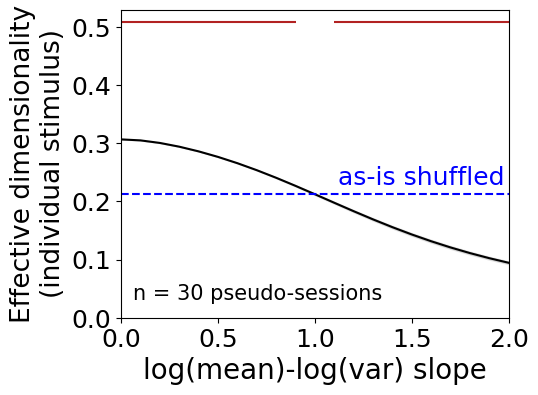

In [17]:
# Effective dimensionality

save_filename = 'eff_dim_DC_Ecker_pooled_neutrialresamp3.pickle.gz' # same as above, halve neurons when resampling, non-overlapping neuron resampling, use raw data in slope fitting, math corrected
with gzip.open(save_filename, 'rb') as f:
    eff_dim_Ecker = pickle.load(f)

    list_dim_asis = eff_dim_Ecker['list_dim_asis'].copy()
    list_dim_RRneuron2 = eff_dim_Ecker['list_dim_RRneuron2'].copy()
    list_dim_global_asis = eff_dim_Ecker['list_dim_global_asis'].copy()
    list_dim_global_RRneuron2 = eff_dim_Ecker['list_dim_global_RRneuron2'].copy()
    list_dim_sam_asis = eff_dim_Ecker['list_dim_sam_asis'].copy()
    list_dim_sam_RRneuron2 = eff_dim_Ecker['list_dim_sam_RRneuron2'].copy()

list_target_slopes = np.linspace(0, 2, 21, endpoint=True)
num_sess = 30
num_trial_types = 75

fig, axes = plt.subplots(1, 1, figsize=(5, 4))
axes = np.array(axes).flatten()

# line plot
list_means_dim = np.nanmean(list_dim_RRneuron2, axis=(0, 2))
list_errs_dim = sem(np.nanmean(list_dim_RRneuron2, axis=2), axis=0)

axes[0].plot(list_target_slopes, list_means_dim, color='k')
axes[0].fill_between(list_target_slopes, list_means_dim-list_errs_dim, list_means_dim+list_errs_dim, color='k', alpha=0.1)

# as-is average
axes[0].axhline(np.nanmean(list_dim_asis), color='b', linestyle='--')

# significance
axes[0].set_ylim(0, 0.53) # line plot, match to mouse shuffled data
list_pvals_dim_Ecker = np.zeros(len(list_target_slopes))
for slope_ind, target_slope in enumerate(list_target_slopes):
    list_pvals_dim_Ecker[slope_ind] = list(wilcoxon(np.nanmean(list_dim_asis, axis=1),
                                                    np.nanmean(list_dim_RRneuron2[:, slope_ind], axis=1), nan_policy='omit'))[1]
list_pvals_dim_Ecker = np.array(multipletests(list_pvals_dim_Ecker, method='holm')[1]) # multiple comparisons correction
list_sig_slopes_dim = list_target_slopes[list_pvals_dim_Ecker < 0.05].copy()
annotate_lineplot_significance(list_sig_slopes_dim, axes=axes, ax_ind=0, line_height_ratio=0.96, color='firebrick')

axes[0].set_xlim(0, 2)
height = (np.nanmean(list_dim_asis)-axes[0].get_ylim()[0]) / (axes[0].get_ylim()[1]-axes[0].get_ylim()[0])
axes[0].annotate('as-is shuffled', xy=(0.56, height+0.03), xycoords='axes fraction', fontsize=18, color='b')

axes[0].set_xlabel('log(mean)-log(var) slope', fontsize=20)
axes[0].set_ylabel('Effective dimensionality\n(individual stimulus)', fontsize=19)
axes[0].tick_params('both', labelsize=18)

# axes[0].legend(loc='upper right', prop={'size': 14})
# axes[0].annotate(f'n = {list_dim_asis.shape[0]} sessions', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k')
axes[0].annotate(f'n = {list_dim_asis.shape[0]} pseudo-sessions', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=15, color='k')

# plt.savefig('code_images\\svg\\monkey_effdim.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\monkey_effdim.png', dpi=300, bbox_inches='tight')
# # plt.savefig('code_images\\svg\\monkey_effdim_interval.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\monkey_effdim_interval.png', dpi=300, bbox_inches='tight')
plt.show()

## Supplementary Figure 15b left

In [18]:
# # Collect decoding for each session (SVM)

# decoder_type = 'SVM'

# list_target_slopes = np.linspace(0, 2, 21, endpoint=True)
# num_sess = 30
# num_trial_types = 75

# list_mean_confusion_test = np.full((num_sess, num_trial_types, num_trial_types), np.nan)
# list_mean_accuracy = np.full(num_sess, np.nan)
# list_mean_confusion_test_RRneuron2 = np.full((len(list_target_slopes), num_sess, num_trial_types, num_trial_types), np.nan)
# list_mean_accuracy_RRneuron2 = np.full((len(list_target_slopes), num_sess), np.nan)
# for sess_ind in range(num_sess):
#     file_name = decoder_type + '_decoding_Ecker_allstim_pooled_neutrialresamp_' + str(sess_ind) + '.pickle.gz'

#     with gzip.open(file_name, 'rb') as f:
#         decoding_ABO = pickle.load(f)

#         list_mean_confusion_test[sess_ind] = decoding_ABO['mean_confusion_test_asis'].copy()
#         list_mean_accuracy[sess_ind] = decoding_ABO['mean_accuracy_asis']
#         list_mean_confusion_test_RRneuron2[:, sess_ind] = decoding_ABO['list_mean_confusion_test_RRneuron'].copy()
#         list_mean_accuracy_RRneuron2[:, sess_ind] = decoding_ABO['list_mean_accuracy_RRneuron'].copy()

# save_file_name = decoder_type + '_decoding_Ecker_allstim_pooled_neutrialresamp_all2.pickle.gz'
# with gzip.open(save_file_name, 'wb') as f:
#     pickle.dump({'tree_variables': ['list_mean_confusion_test', 'list_mean_accuracy', 'list_mean_confusion_test_RRneuron2', 'list_mean_accuracy_RRneuron2'],
#                     'list_mean_confusion_test': list_mean_confusion_test, 'list_mean_accuracy': list_mean_accuracy,
#                     'list_mean_confusion_test_RRneuron2': list_mean_confusion_test_RRneuron2, 'list_mean_accuracy_RRneuron2': list_mean_accuracy_RRneuron2}, f)

c:\Users\USER\anaconda3\envs\allensdk_ep_mod_test\Lib\site-packages\scipy\stats\_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "


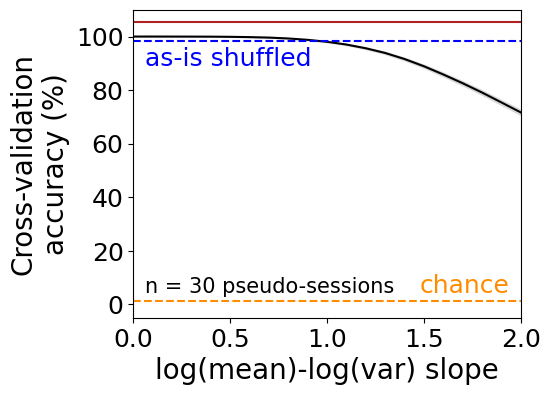

In [19]:
# decoding plot across slopes (ABO, SVM)

decoder_type = 'SVM'

save_file_name = decoder_type + '_decoding_Ecker_allstim_pooled_neutrialresamp_all2.pickle.gz' # SVM max_iter=1000, halve neurons when resampling, non-overlapping neuron resampling, use raw data in slope fitting
with gzip.open(save_file_name, 'rb') as f:
    decoding_all = pickle.load(f)

    # list_mean_confusion_test = dc(decoding_all['list_mean_confusion_test'])
    list_mean_accuracy = dc(decoding_all['list_mean_accuracy'])
    # list_mean_confusion_test_RRneuron2 = dc(decoding_all['list_mean_confusion_test_RRneuron2'])
    list_mean_accuracy_RRneuron2 = dc(decoding_all['list_mean_accuracy_RRneuron2'])

list_mean_accuracy = 100 * list_mean_accuracy
list_mean_accuracy_RRneuron2 = 100 * list_mean_accuracy_RRneuron2

list_target_slopes = np.linspace(0, 2, 21, endpoint=True)
num_trial_types = 75

# As-is vs. RRneuron test accuracy bar graph (averaged across sessions)
fig, axes = plt.subplots(1, 1, figsize=(5, 4))
axes = np.array(axes).flatten()

# test accuracy

# line plot
list_means_accuracy = np.array([np.mean(list_mean_accuracy_RRneuron2[slope_ind]) \
                       for slope_ind in range(len(list_target_slopes))])
list_errs_accuracy = np.array([sem(list_mean_accuracy_RRneuron2[slope_ind]) \
                      for slope_ind in range(len(list_target_slopes))])

axes[0].plot(list_target_slopes, list_means_accuracy, color='k', label='monkey')
axes[0].fill_between(list_target_slopes, list_means_accuracy-list_errs_accuracy, \
                     list_means_accuracy+list_errs_accuracy, color='k', alpha=0.1)

# as-is
axes[0].axhline(np.mean(list_mean_accuracy), c='b', linestyle='--')

# significance
axes[0].set_ylim(axes[0].get_ylim()[0], axes[0].get_ylim()[1])
axes[0].set_ylim(-5, 110) # match to mouse shuffled data
list_pvals_RRneuron2 = np.zeros(len(list_target_slopes)) # test accuracy
for slope_ind, slope in enumerate(list_target_slopes):
    list_pvals_RRneuron2[slope_ind] = list(wilcoxon(list_mean_accuracy, list_mean_accuracy_RRneuron2[slope_ind]))[1]
list_pvals_RRneuron2 = np.array(multipletests(list_pvals_RRneuron2, method='holm')[1]) # multiple comparisons correction
annotate_lineplot_significance(list_target_slopes[list_pvals_RRneuron2 < 0.05], axes=axes, ax_ind=0, line_height_ratio=0.96, color='firebrick')

axes[0].set_xlim(0, 2)
height = (np.mean(list_mean_accuracy)-axes[0].get_ylim()[0]) / (axes[0].get_ylim()[1] - axes[0].get_ylim()[0])
axes[0].annotate('as-is shuffled', xy=(0.03, height-0.08), xycoords='axes fraction', fontsize=18, color='b')

axes[0].set_xlabel('log(mean)-log(var) slope', fontsize=20)
axes[0].set_ylabel('Cross-validation\naccuracy (%)', fontsize=20)
axes[0].tick_params('both', labelsize=18)

# axes[0].legend(loc='upper left', bbox_to_anchor=(1, 1), prop={'size': 14})
axes[0].annotate(f'n = {list_mean_accuracy.shape[0]} pseudo-sessions', xy=(0.03, 0.08), xycoords='axes fraction', fontsize=15, color='k')
axes[0].axhline(100*1/num_trial_types, c='darkorange', linestyle='--') # chance level
axes[0].annotate(f'chance', xy=(0.74, 0.08), xycoords='axes fraction', fontsize=18, color='darkorange')

# plt.savefig('code_images\\svg\\monkey_decoding.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\monkey_decoding.png', dpi=300, bbox_inches='tight')
# # plt.savefig('code_images\\svg\\monkey_decoding_interval.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\monkey_decoding_interval.png', dpi=300, bbox_inches='tight')
plt.show()

## Supplementary Figure 15c left

In [20]:
# # Collect correlation for each session (within session)
# similarity_type = 'cos_sim'
# # similarity_type = 'geodesic'
# # similarity_type = 'euclidean'

# list_target_slopes = np.linspace(0, 2, 21, endpoint=True)
# num_sess = 30
# n_neu_sampling = 10

# list_corr_withinsess_asis2 = np.zeros((num_sess, n_neu_sampling, 3))
# list_corr_withinsess3 = np.zeros((num_sess, len(list_target_slopes), n_neu_sampling, 3))
# for sess_ind in range(num_sess):
#     file_name = 'RSM_corr_withinsess_Ecker_pooled_neutrialresamp_' + similarity_type + str(sess_ind) + '.pickle.gz'
    
#     with gzip.open(file_name, 'rb') as f:
#         RSM_corr_withinsess_Ecker = pickle.load(f)

#         list_corr_withinsess_asis2[sess_ind] = RSM_corr_withinsess_Ecker['list_corr_withinsess_asis'].copy()
#         list_corr_withinsess3[sess_ind] = RSM_corr_withinsess_Ecker['list_corr_withinsess2'].copy()

# save_file_name = 'RSM_corr_withinsess_Ecker_pooled_neutrialresamp_all3_' + similarity_type + '.pickle.gz'
# with gzip.open(save_file_name, 'wb') as f:
#     pickle.dump({'tree_variables': ['list_corr_withinsess_asis2', 'list_corr_withinsess3'], \
#                  'list_corr_withinsess_asis2': list_corr_withinsess_asis2, 'list_corr_withinsess3': list_corr_withinsess3}, f)

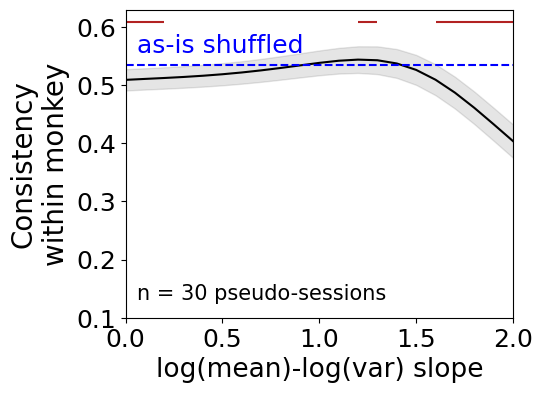

In [21]:
# RSA within session

similarity_type = 'cos_sim'

save_file_name = 'RSM_corr_withinsess_Ecker_pooled_neutrialresamp_all2_' + similarity_type + '.pickle.gz' # include as-is, trial combination, monkey session pooling, halve neurons when resampling, non-overlapping neuron resampling, use raw data in slope fitting
with gzip.open(save_file_name, 'rb') as f:
    RSM_corr_withinsess_Ecker_all = pickle.load(f)
    list_corr_withinsess_asis2 = RSM_corr_withinsess_Ecker_all['list_corr_withinsess_asis2'].copy()
    list_corr_withinsess3 = RSM_corr_withinsess_Ecker_all['list_corr_withinsess3'].copy()

num_sess = 30
list_target_slopes = np.linspace(0, 2, 21, endpoint=True)

corr_ind = 0

fig, axes = plt.subplots(1, 1, figsize=(5, 4))
axes = np.array(axes).flatten()

# line plot
list_means_corr_withinsess = np.nanmean(list_corr_withinsess3[:, :, :, corr_ind], axis=(0, 2))
list_errs_corr_withinsess = sem(np.nanmean(list_corr_withinsess3[:, :, :, corr_ind], axis=2), axis=0, nan_policy='omit')

axes[0].plot(list_target_slopes, list_means_corr_withinsess, color='k')
axes[0].fill_between(list_target_slopes, list_means_corr_withinsess-list_errs_corr_withinsess, \
                     list_means_corr_withinsess+list_errs_corr_withinsess, color='k', alpha=0.1)

# as-is
axes[0].axhline(np.nanmean(list_corr_withinsess_asis2[:, :, corr_ind]), c='b', linestyle='--', label='as-is')

# significance
# axes[0].set_ylim(axes[0].get_ylim()[0], 0.5)
axes[0].set_ylim(0.1, 0.63) # match to mouse shuffled data
list_pvals_corr_withinsess_Ecker = np.full((3, len(list_target_slopes)), np.nan)
for corr_ind in range(3):
    pvals_temp = [list(wilcoxon(list_corr_withinsess_asis2[:, :, corr_ind].mean(axis=1), list_corr_withinsess3[:, slope_ind, :, corr_ind].mean(axis=1)))[1]\
                  for slope_ind in range(len(list_target_slopes))]
    pvals_temp = np.array(multipletests(pvals_temp, method='holm')[1]) # multiple comparisons correction
    list_pvals_corr_withinsess_Ecker[corr_ind] = pvals_temp.copy()
corr_ind = 0
list_sig_slopes_corr_withinsess = list_target_slopes[list_pvals_corr_withinsess_Ecker[corr_ind] < 0.05].copy()
annotate_lineplot_significance(list_sig_slopes_corr_withinsess, axes=axes, ax_ind=0, line_height_ratio=0.96, color='firebrick')

axes[0].set_xlim(0, 2)
height = (np.nanmean(list_corr_withinsess_asis2[:, :, corr_ind])-axes[0].get_ylim()[0]) / (axes[0].get_ylim()[1]-axes[0].get_ylim()[0])
axes[0].annotate('as-is shuffled', xy=(0.03, height+0.04), xycoords='axes fraction', fontsize=18, color='b')

axes[0].set_xlabel('log(mean)-log(var) slope', fontsize=19)
axes[0].set_ylabel('Similarity of RSMs\nbetween neuronal subsets', fontsize=17)
axes[0].set_ylabel('Similarity within monkey', fontsize=18)
axes[0].set_ylabel('Consistency\nwithin monkey', fontsize=20)
# axes[0].set_ylabel('Consistency\nwithin session', fontsize=20)
axes[0].tick_params('both', labelsize=18)

# axes[0].annotate(f'n = {list_corr_withinsess_asis2.shape[0]} sessions', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k')
axes[0].annotate(f'n = {list_corr_withinsess_asis2.shape[0]} pseudo-sessions', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=15, color='k')

# plt.savefig('code_images\\svg\\monkey_RSA_within.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\monkey_RSA_within.png', dpi=300, bbox_inches='tight')
# # plt.savefig('code_images\\svg\\monkey_RSA_within_interval.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\monkey_RSA_within_interval.png', dpi=300, bbox_inches='tight')
plt.show()

## Supplementary Figure 15d left

In [22]:
# # Collect RSM for each session (across session pairs)
# similarity_type = 'geodesic'
# similarity_type = 'cos_sim'
# # similarity_type = 'euclidean'

# list_target_slopes = np.linspace(0, 2, 21, endpoint=True)
# num_sess = 30
# num_trial_types = 75

# list_RSM_mean_asis_Ecker = np.full((num_sess, num_trial_types, num_trial_types), np.nan)
# list_RSM_mean_RRneuron2 = np.full((num_sess, len(list_target_slopes), num_trial_types, num_trial_types), np.nan)
# list_rate_RRneuron_dr2 = np.empty(num_sess, dtype=object)
# for sess_ind in range(num_sess):
#     file_name = 'RSM_Ecker_allneu_pooled_neutrialresamp_' + similarity_type + str(sess_ind) + '.pickle.gz'

#     with gzip.open(file_name, 'rb') as f:
#         RSM_Ecker = pickle.load(f)
#         list_RSM_mean_asis_Ecker[sess_ind] = RSM_Ecker['list_RSM_mean_asis'].copy()
#         list_RSM_mean_RRneuron2[sess_ind] = RSM_Ecker['list_RSM_mean_RRneuron'].copy()
#         list_rate_RRneuron_dr2[sess_ind] = RSM_Ecker['list_rate_RRneuron_dr'].copy()

# # # Spearman correlation across session pairs (session pairs only between different monkeys)
# # subject_unique, subject_counts = np.unique(subject_ids, return_counts=True) # 2 monkeys
# # sess_pairs = list(product(np.where(subject_ids == subject_unique[0])[0], np.where(subject_ids == subject_unique[1])[0]))
# # sess_pairs = list(combinations(range(num_sess), 2)) # monkey session pooling
# sess_pairs = list(product(np.arange(num_sess//2), np.arange(num_sess//2)+num_sess//2))
# list_corr_sesspair_asis_Ecker = np.zeros((len(sess_pairs), 3))
# list_corr_sesspair2 = np.zeros((len(sess_pairs), len(list_target_slopes), 3))
# for pair_ind, pair in enumerate(sess_pairs):
#     RSM_mean_neu1 = list_RSM_mean_asis_Ecker[pair[0]].copy() # subject id 30 (M2)
#     RSM_mean_neu2 = list_RSM_mean_asis_Ecker[pair[1]].copy() # subject id 31 (M1)

#     list_corr_sesspair_asis_Ecker[pair_ind, 0] = spearmanr(RSM_mean_neu1.flatten(), RSM_mean_neu2.flatten(), nan_policy='omit').statistic
#     bool_notnan = np.logical_and(~np.isnan(RSM_mean_neu1.flatten()), ~np.isnan(RSM_mean_neu2.flatten()))
#     list_corr_sesspair_asis_Ecker[pair_ind, 1] = np.corrcoef(RSM_mean_neu1.flatten()[bool_notnan], RSM_mean_neu2.flatten()[bool_notnan])[0, 1]
#     list_corr_sesspair_asis_Ecker[pair_ind, 2] = cos_sim(RSM_mean_neu1.flatten(), RSM_mean_neu2.flatten())
    
#     for slope_ind, target_slope in enumerate(list_target_slopes):
#         RSM_mean_neu1 = list_RSM_mean_RRneuron2[pair[0], slope_ind].copy() # subject id 30 (M2)
#         RSM_mean_neu2 = list_RSM_mean_RRneuron2[pair[1], slope_ind].copy() # subject id 31 (M1)

#         list_corr_sesspair2[pair_ind, slope_ind, 0] = spearmanr(RSM_mean_neu1.flatten(), RSM_mean_neu2.flatten(), nan_policy='omit').statistic
#         bool_notnan = np.logical_and(~np.isnan(RSM_mean_neu1.flatten()), ~np.isnan(RSM_mean_neu2.flatten()))
#         list_corr_sesspair2[pair_ind, slope_ind, 1] = np.corrcoef(RSM_mean_neu1.flatten()[bool_notnan], RSM_mean_neu2.flatten()[bool_notnan])[0, 1]
#         list_corr_sesspair2[pair_ind, slope_ind, 2] = cos_sim(RSM_mean_neu1.flatten(), RSM_mean_neu2.flatten())

# save_file_name = 'RSM_Ecker_all_allneu3_pooled_neutrialresamp_' + similarity_type + '.pickle.gz'
# with gzip.open(save_file_name, 'wb') as f:
#     pickle.dump({'tree_variables': ['list_RSM_mean_asis_Ecker', 'list_corr_sesspair_asis_Ecker', 'list_rate_RRneuron_dr2', 'list_RSM_mean_RRneuron2', 'list_corr_sesspair2'], \
#                  'list_RSM_mean_asis_Ecker': list_RSM_mean_asis_Ecker, 'list_corr_sesspair_asis_Ecker': list_corr_sesspair_asis_Ecker,
#                  'list_rate_RRneuron_dr2': list_rate_RRneuron_dr2, 'list_RSM_mean_RRneuron2': list_RSM_mean_RRneuron2, 'list_corr_sesspair2': list_corr_sesspair2}, f)

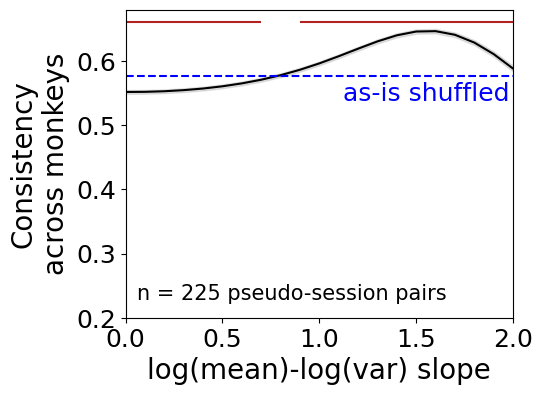

In [23]:
# RSA across sessions
similarity_type = 'cos_sim'

save_file_name = 'RSM_Ecker_all_allneu2_pooled_neutrialresamp_' + similarity_type + '.pickle.gz' # trial order matched, monkey session pooling, halve neurons when resampling, non-overlapping neuron resampling, use raw data in slope fitting
with gzip.open(save_file_name, 'rb') as f:
    RSM_Ecker_all = pickle.load(f)
    list_corr_sesspair_asis_Ecker = RSM_Ecker_all['list_corr_sesspair_asis_Ecker'].copy()
    list_corr_sesspair2 = RSM_Ecker_all['list_corr_sesspair2'].copy()

list_target_slopes = np.linspace(0, 2, 21, endpoint=True)
num_sess = 30

corr_ind = 0

fig, axes = plt.subplots(1, 1, figsize=(5, 4))
axes = np.array(axes).flatten()

# line plot
x = list_target_slopes.copy()
list_means_corr_sesspair = np.nanmean(list_corr_sesspair2[:, :, corr_ind], axis=0)
list_errs_corr_sesspair = sem(list_corr_sesspair2[:, :, corr_ind], axis=0, nan_policy='omit')

axes[0].plot(list_target_slopes, list_means_corr_sesspair, color='k', label='original')
axes[0].fill_between(list_target_slopes, list_means_corr_sesspair-list_errs_corr_sesspair, \
                     list_means_corr_sesspair+list_errs_corr_sesspair, color='k', alpha=0.1)

# as-is
axes[0].axhline(np.nanmean(list_corr_sesspair_asis_Ecker[:, corr_ind]), c='b', linestyle='--')

# significance
axes[0].set_ylim(axes[0].get_ylim()[0], axes[0].get_ylim()[1])
axes[0].set_ylim(0.2, 0.68) # match to mouse shuffled data
list_pvals_corr_sesspair_Ecker = np.full((3, len(list_target_slopes)), np.nan)
for corr_ind in range(3):
    pvals_temp = [list(wilcoxon(list_corr_sesspair_asis_Ecker[:, corr_ind], list_corr_sesspair2[:, slope_ind, corr_ind], nan_policy='omit'))[1]\
                  for slope_ind in range(len(list_target_slopes))]
    pvals_temp = np.array(multipletests(pvals_temp, method='holm')[1]) # multiple comparisons correction
    list_pvals_corr_sesspair_Ecker[corr_ind] = pvals_temp.copy()
corr_ind = 0
list_sig_slopes_corr_sesspair = list_target_slopes[list_pvals_corr_sesspair_Ecker[corr_ind] < 0.05].copy()
annotate_lineplot_significance(list_sig_slopes_corr_sesspair, axes=axes, ax_ind=0, line_height_ratio=0.96, color='firebrick')

axes[0].set_xlim(0, 2)
height = (np.nanmean(list_corr_sesspair_asis_Ecker[:, corr_ind])-axes[0].get_ylim()[0]) / (axes[0].get_ylim()[1]-axes[0].get_ylim()[0])
axes[0].annotate('as-is shuffled', xy=(0.56, height-0.08), xycoords='axes fraction', fontsize=18, color='b')

axes[0].set_xlabel('log(mean)-log(var) slope', fontsize=20)
axes[0].set_ylabel('Similarity of RSMs\nbetween session pairs', fontsize=20)
axes[0].set_ylabel('Similarity across monkeys', fontsize=17)
axes[0].set_ylabel('Consistency\nacross monkeys', fontsize=20)
# axes[0].set_ylabel('Consistency\nacross sessions', fontsize=20)
axes[0].tick_params('both', labelsize=18)

# axes[0].annotate(f'n = {list_corr_sesspair2.shape[0]} session pairs', xy=(0.35, 0.06), xycoords='axes fraction', fontsize=18, color='k')
axes[0].annotate(f'n = {list_corr_sesspair2.shape[0]} pseudo-session pairs', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=15, color='k')

# plt.savefig('code_images\\svg\\monkey_RSA_across.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\monkey_RSA_across.png', dpi=300, bbox_inches='tight')
# # plt.savefig('code_images\\svg\\monkey_RSA_across_interval.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\monkey_RSA_across_interval.png', dpi=300, bbox_inches='tight')
plt.show()